In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-17T18:21:42.121964+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

marimo    : 0.23.2
pandas    : 2.2.3
requests  : 2.34.2
numpy     : 2.1.2
seaborn   : 0.13.2
matplotlib: 3.10.7
teeplot   : 1.4.2

```

## Data

The **2-site** companion to
`bindle/2026-06-17-3site-strain-trajectories.py`. Load the
per-replicate **strain** and **Hamming-weight** prevalence time
series for the 2-site model (`N_SITES=2`, so genomes are `00, 01, 10,
11` --- strain indices `0 .. 3` --- and Hamming weights run `0 .. 2`).
The mutation-rate sweep covers 7 conditions spanning `1e-4` to `1e-1`
(~2 points per decade), 5000 steps per replicate,
POP_SIZE=1_000_000, on CPU (engine=numpy).

Four long-form frames back this notebook, keyed by `replicate_uid`
and `Step`:

- **strain-samples** (`gycde`): per-genome prevalence **trajectory**
  (one row per `(replicate_uid, Step, strain)`), a handful of
  replicates per rate --- backs the trellis solid lines.
- **hw-samples** (`96gxr`): per-Hamming-weight band prevalence
  **trajectory** (one row per `(replicate_uid, Step, hw)`) --- backs
  the trellis dashed lines.
- **strain-final** (`ybgwp`): per-genome **end state** only (final
  step, ~200 replicates per rate) --- backs the end-state
  complement-absence statistics.
- **hw-final** (`x7qmt`): per-Hamming-weight band **end state** ---
  loaded for reference (the complement statistic needs the
  per-genome `strain-final` frame, so `hw-final` is not plotted
  here).

This is a **visualization notebook** (no CLI arguments): the OSF
slugs are hard-coded below and downloaded with `requests`, cached at
`/tmp/<slug>` so re-runs hit the local copy.

In [ ]:
# Shared OSF fetcher with /tmp caching (this is a visualization
# notebook with no CLI arguments --- all slugs are hard-coded).
def fetch_osf(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=240)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_parquet(cache_path)

In [ ]:
# strain-samples (gycde) = per-genome prevalence trajectory;
# hw-samples (96gxr) = per-Hamming-weight band prevalence trajectory.
# These back the replicate trajectory trellis.
strain_df = fetch_osf("gycde")
hw_df = fetch_osf("96gxr")
print(f"loaded strain-samples dataframe: {strain_df.shape}")
print(f"loaded hw-samples dataframe: {hw_df.shape}")
print(
    "mutation_rate x replicate counts (hw):\n"
    + str(hw_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

downloading https://osf.io/gycde/download -> /tmp/gycde
size: 6134976 bytes
downloading https://osf.io/96gxr/download -> /tmp/96gxr
size: 2311068 bytes
loaded strain-samples dataframe: (420000, 23)
loaded hw-samples dataframe: (315000, 20)
mutation_rate x replicate counts (hw):
mutation_rate
0.0001    3
0.0003    3
0.0010    3
0.0030    3
0.0100    3
0.0300    3
0.1000    3
Name: replicate_uid, dtype: int64


In [ ]:
# strain-final (ybgwp) = per-genome END-STATE (final step only) with
# ~200 replicates per mutation rate --- backs the end-state
# complement-absence statistics.
strain_final_df = fetch_osf("ybgwp")
print(f"loaded strain-final dataframe: {strain_final_df.shape}")
print(
    "mutation_rate x replicate counts (strain-final):\n"
    + str(
        strain_final_df.groupby("mutation_rate")[
            "replicate_uid"
        ].nunique(),
    ),
)

downloading https://osf.io/ybgwp/download -> /tmp/ybgwp
size: 188712 bytes
loaded strain-final dataframe: (5016, 23)
mutation_rate x replicate counts (strain-final):
mutation_rate
0.0001     76
0.0003    194
0.0010    193
0.0030    191
0.0100    200
0.0300    200
0.1000    200
Name: replicate_uid, dtype: int64


## Hamming-Weight Coloring & Trellis Builder

Tag every strain genome with its **Hamming weight** (`bit-count`) so
the per-genome curves can be colored by weight, matching the
aggregated `hw` bands. Then define a reusable `make_trellis` helper
that, for an optional **step window** (`step_clip`), clips both frames
to the first `step_clip` updates and renders the replicate trellis:
**one column per `mutation_rate`** (power-of-ten rates only, so
`1e-4 .. 1e-1`, increasing **left to right**) and **one row per
within-rate replicate** (ordered by `replicate_uid`). Per-step series
are subsampled by a window-dependent `STRIDE` so each line carries at
most ~1000 points.

In [ ]:
N_SITES = int(hw_df["n_sites"].iloc[0])
# Hamming weight of each genome == popcount of the strain index.
strain_hw_df = strain_df.assign(
    hw=strain_df["strain"].map(lambda _s: bin(int(_s)).count("1")),
)

In [ ]:
# Categorical Hamming-weight palette (2-site): extreme weights 0 & 2
# (founder 00 and complement 11) cool, intermediate weight 1 warm.
_HW_COLORS = ["#2b6cb0", "#c53030", "#38b2ac"]

def make_trellis(hw_df, strain_hw_df, N_SITES, step_clip=None):
    # Clip both frames to the first ``step_clip`` updates (or keep the
    # full run when ``step_clip`` is None).
    if step_clip is None:
        _hw, _strain = hw_df, strain_hw_df
        _clip_tag, _clip_label = "full", "all updates"
    else:
        _hw = hw_df[hw_df["Step"] < step_clip]
        _strain = strain_hw_df[strain_hw_df["Step"] < step_clip]
        _clip_tag, _clip_label = (
            str(step_clip),
            f"first {step_clip} updates",
        )
    stride = max(1, int(_strain["Step"].nunique()) // 1000)

    # Power-of-ten mutation rates (ascending).
    rate_vals = [
        _r
        for _r in sorted(_hw["mutation_rate"].unique().tolist())
        if f"{_r:.0e}".startswith("1e")
    ]
    reps_by_rate = {
        _rate: sorted(
            _hw[_hw["mutation_rate"] == _rate]["replicate_uid"].unique(),
        )
        for _rate in rate_vals
    }
    max_reps = max(len(_r) for _r in reps_by_rate.values())
    n_cols = len(rate_vals)
    n_rows = int(max_reps)
    print(
        f"clip={_clip_tag} stride={stride} "
        f"grid={n_rows} replicates x {n_cols} rates",
    )

    with tp.teed(
        plt.subplots,
        nrows=n_rows,
        ncols=n_cols,
        figsize=(2.3 * n_cols, 1.4 * n_rows),
        sharex=True,
        squeeze=False,
        teeplot_outattrs={
            "a": "strain-vs-hw-replicate-trellis",
            "clip": _clip_tag,
        },
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        for _i, _rate in enumerate(rate_vals):
            _reps = reps_by_rate[_rate]
            for _j in range(n_rows):
                _ax = axes[_j][_i]
                if _j >= len(_reps):
                    _ax.axis("off")
                    continue
                _rid = _reps[_j]
                _h = _hw[_hw["replicate_uid"] == _rid].sort_values("Step")
                _s = _strain[_strain["replicate_uid"] == _rid].sort_values(
                    "Step"
                )

                # Solid: per-genome strain prevalence, colored by hw.
                for _strn in sorted(_s["strain"].unique()):
                    _ss = _s[_s["strain"] == _strn].iloc[::stride]
                    _w = bin(int(_strn)).count("1")
                    _ax.plot(
                        _ss["Step"],
                        _ss["count"],
                        linestyle="-",
                        linewidth=0.7,
                        color=_HW_COLORS[_w],
                        alpha=0.8,
                    )
                # Dashed: aggregated Hamming-weight band prevalence.
                for _w in range(N_SITES + 1):
                    _hh = _h[_h["hw"] == _w].iloc[::stride]
                    _ax.plot(
                        _hh["Step"],
                        _hh["count"],
                        linestyle="--",
                        linewidth=1.0,
                        color=_HW_COLORS[_w],
                        alpha=0.95,
                    )

                _ax.set_ylim(bottom=0)
                _ax.tick_params(labelsize=6)
                if _i == 0:
                    _ax.set_ylabel(
                        f"replicate {_j}\nprevalence",
                        fontsize=7,
                    )
                if _j == 0:
                    _ax.set_title(f"$\\mu$={_rate:.0e}", fontsize=8)
                if _j == n_rows - 1:
                    _ax.set_xlabel("Step", fontsize=7)
                sns.despine(ax=_ax)

        # Shared legend: Hamming-weight colors + line-style meaning.
        _handles = [
            mlines.Line2D(
                [],
                [],
                color=_HW_COLORS[_w],
                linewidth=2.0,
                label=f"HW {_w}",
            )
            for _w in range(N_SITES + 1)
        ]
        _handles += [
            mlines.Line2D(
                [],
                [],
                color="black",
                linestyle="-",
                linewidth=1.2,
                label="strain (per genome)",
            ),
            mlines.Line2D(
                [],
                [],
                color="black",
                linestyle="--",
                linewidth=1.2,
                label="Hamming-weight band",
            ),
        ]
        fig.suptitle(_clip_label, y=1.02, fontsize=11)
        fig.legend(
            handles=_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.005),
            ncol=len(_handles),
            frameon=False,
            fontsize=8,
        )
        fig.tight_layout(rect=(0, 0, 1, 0.98))

## Trellis --- Full Run (All Updates)

One panel per replicate, trellised by `mutation_rate` (columns,
increasing left to right, power-of-ten rates `1e-4 .. 1e-1`) over
within-rate replicates (rows). In each panel:

- **solid** lines are individual **strain** (per-genome) prevalence
  trajectories, **color-coded by Hamming weight**;
- **dashed** lines are the aggregated **Hamming-weight band**
  prevalences in the same color scheme.

Hamming weights use a categorical palette in which the **extreme
weights `0` and `2`** (the founder `00` and its complement `11`) are
**cool** (blue / cyan) and the **intermediate weight `1`** is **warm**
(red). These are individual replicate trajectories, so **no
confidence interval** is drawn --- every line is one realized run.
The dashed band of a given color is the sum of the solid strain
curves sharing that Hamming weight.

clip=full stride=5 grid=3 replicates x 4 rates
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=full+viz=subplots+ext=.pdf
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=full+viz=subplots+ext=.png


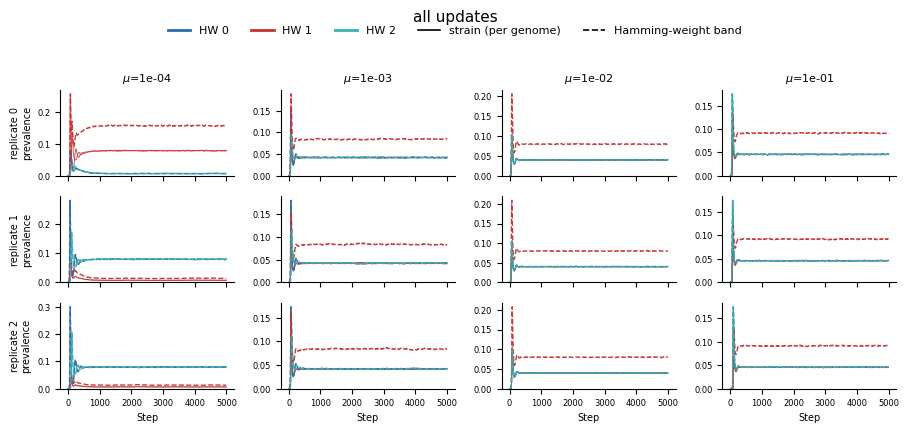

In [ ]:
make_trellis(hw_df, strain_hw_df, N_SITES, step_clip=None)

## Trellis --- First 2000 Updates

The same trellis clipped to the first **2000** updates to zoom in on
the establishment phase and the start of the endemic plateau.

clip=2000 stride=2 grid=3 replicates x 4 rates
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=2000+viz=subplots+ext=.pdf
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=2000+viz=subplots+ext=.png


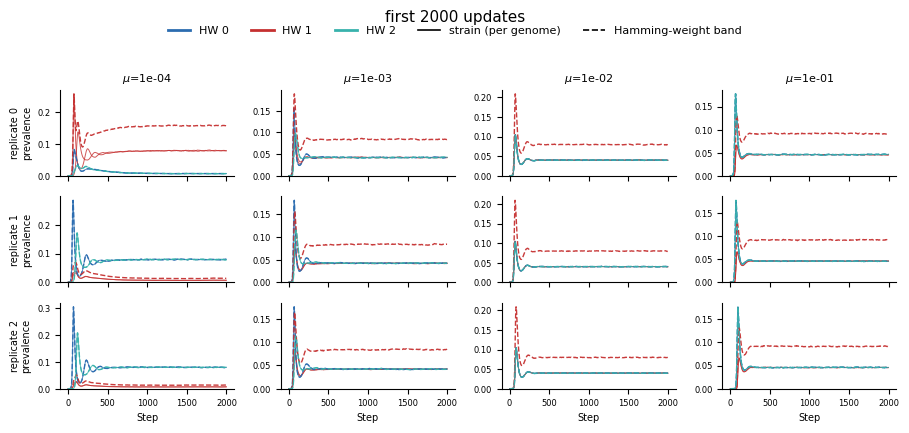

In [ ]:
make_trellis(hw_df, strain_hw_df, N_SITES, step_clip=2000)

## Trellis --- First 400 Updates

Clipped tighter, to the first **400** updates, to resolve the early
outbreak peak and the first strain-divergence transient before the
bands settle.

clip=400 stride=1 grid=3 replicates x 4 rates
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=400+viz=subplots+ext=.pdf
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=400+viz=subplots+ext=.png


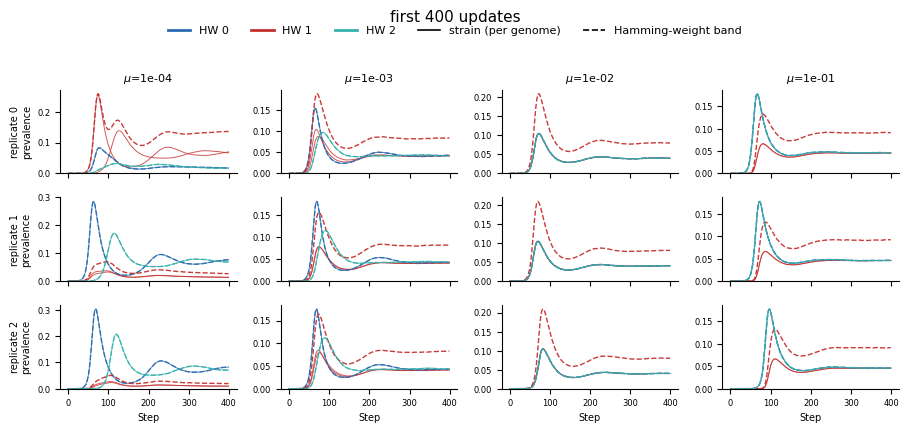

In [ ]:
make_trellis(hw_df, strain_hw_df, N_SITES, step_clip=400)

## Trellis --- First 200 Updates

The tightest zoom, to the first **200** updates, isolating the
initial founder-driven epidemic wave and the very first appearance
of mutant strains.

clip=200 stride=1 grid=3 replicates x 4 rates
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=200+viz=subplots+ext=.pdf
teeplots/2026-06-17-2site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=200+viz=subplots+ext=.png


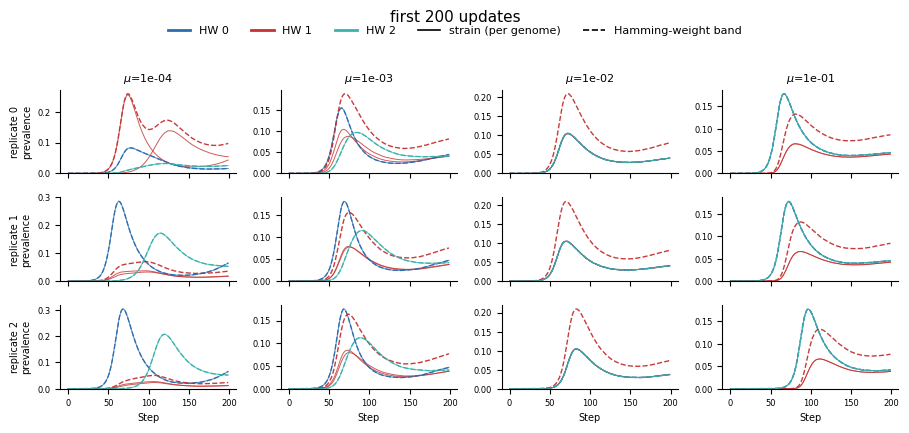

In [ ]:
make_trellis(hw_df, strain_hw_df, N_SITES, step_clip=200)

## End-State Dominant-Strain Complement Absence

Using the higher-replicate **`strain-final`** end-state snapshot
(~200 replicates per rate), for each replicate identify the
**dominant strain** (the genome with the most cases). Its **bitwise
complement** is the genome with every allele flipped (`strain ^
(2**N_SITES - 1)`) --- e.g. the complement of the founder `00` is
`11`, and the complement of `01` is `10`. The complement always
shares the dominant strain's "opposite" Hamming weight `N_SITES - hw`.

We then plot, **per `mutation_rate`**, the **fraction of replicates
in which the complement is _absent_** (zero cases) at the final step.
A high fraction means end states tend to be one-sided; a low fraction
means the complementary genome typically coexists. All 7 swept rates
are shown on a log x-axis.

In [ ]:
_mask = (1 << N_SITES) - 1

# strain-final already holds one final-step snapshot per replicate.
_rows = []
for _rid, _sub in strain_final_df.groupby("replicate_uid"):
    _dom = int(_sub.loc[_sub["n_cases"].idxmax(), "strain"])
    _dom_hw = bin(_dom).count("1")
    _comp = _dom ^ _mask
    _comp_cases = int(
        _sub.loc[_sub["strain"] == _comp, "n_cases"].iloc[0],
    )
    _rows.append(
        {
            "replicate_uid": _rid,
            "mutation_rate": float(_sub["mutation_rate"].iloc[0]),
            "dominant_strain": _dom,
            "dominant_hw": _dom_hw,
            # Founder class == extreme Hamming weights {0, N_SITES};
            # intermediate == {1}.
            "dominant_class": (
                "founder (HW 0/2)"
                if _dom_hw in (0, N_SITES)
                else "intermediate (HW 1)"
            ),
            "complement_strain": _comp,
            "complement_cases": _comp_cases,
            "complement_absent": _comp_cases == 0,
        },
    )
complement_df = pd.DataFrame(_rows)
print(f"complement frame: {complement_df.shape}")

complement frame: (1254, 8)


 mutation_rate  frac_absent  n_absent  n_total
        0.0001          0.0         0       76
        0.0003          0.0         0      194
        0.0010          0.0         0      193
        0.0030          0.0         0      191
        0.0100          0.0         0      200
        0.0300          0.0         0      200
        0.1000          0.0         0      200
teeplots/2026-06-17-2site-strain-trajectories/a=dominant-complement-absent-fraction+color=6a3d9a+marker=o+viz=lineplot+x=mutation-rate+y=frac-absent+ext=.pdf
teeplots/2026-06-17-2site-strain-trajectories/a=dominant-complement-absent-fraction+color=6a3d9a+marker=o+viz=lineplot+x=mutation-rate+y=frac-absent+ext=.png


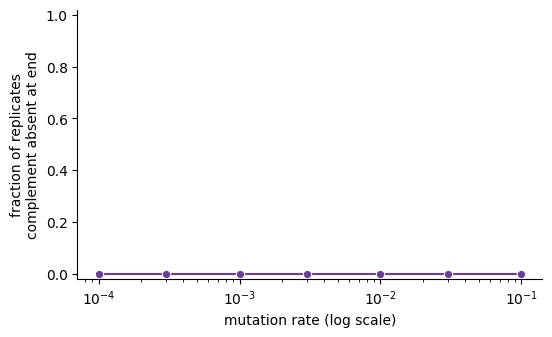

In [ ]:
_frac_df = (
    complement_df.groupby("mutation_rate")["complement_absent"]
    .agg(frac_absent="mean", n_absent="sum", n_total="count")
    .reset_index()
    .sort_values("mutation_rate")
)
print(_frac_df.to_string(index=False))

with tp.teed(
    sns.lineplot,
    data=_frac_df,
    x="mutation_rate",
    y="frac_absent",
    marker="o",
    color="#6a3d9a",
    teeplot_outattrs={"a": "dominant-complement-absent-fraction"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel(
        "fraction of replicates\ncomplement absent at end",
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(6, 3.5)

## Complement Absence Split by Dominant Hamming-Weight Class

The same end-state statistic, but with replicates **split by the
Hamming-weight class of the final dominant strain**: **founder**
(extreme weights `0`/`2` --- the founder `00` and its complement
`11`) versus **intermediate** (weight `1`). Each line is the fraction
of replicates *within that class* whose dominant-strain complement is
absent at the final step, per mutation rate. (Where a class has no
replicates at a given rate it simply has no point.)

 mutation_rate      dominant_class  frac_absent  n_absent  n_total
        0.0001    founder (HW 0/2)          0.0         0       74
        0.0003    founder (HW 0/2)          0.0         0      188
        0.0010    founder (HW 0/2)          0.0         0       84
        0.0030    founder (HW 0/2)          0.0         0       90
        0.0100    founder (HW 0/2)          0.0         0       95
        0.0300    founder (HW 0/2)          0.0         0      103
        0.1000    founder (HW 0/2)          0.0         0       98
        0.0001 intermediate (HW 1)          0.0         0        2
        0.0003 intermediate (HW 1)          0.0         0        6
        0.0010 intermediate (HW 1)          0.0         0      109
        0.0030 intermediate (HW 1)          0.0         0      101
        0.0100 intermediate (HW 1)          0.0         0      105
        0.0300 intermediate (HW 1)          0.0         0       97
        0.1000 intermediate (HW 1)          0.0         0     

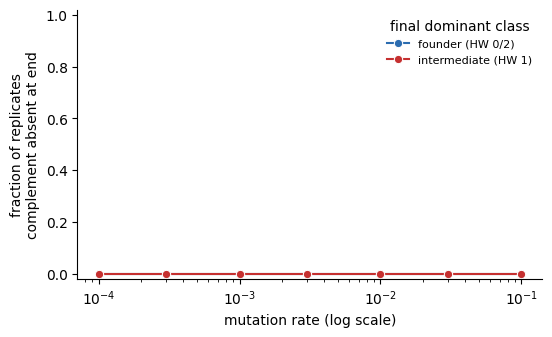

In [ ]:
_class_order = ["founder (HW 0/2)", "intermediate (HW 1)"]
_palette = {
    "founder (HW 0/2)": "#2b6cb0",
    "intermediate (HW 1)": "#c53030",
}
_frac_df = (
    complement_df.groupby(["mutation_rate", "dominant_class"])[
        "complement_absent"
    ]
    .agg(frac_absent="mean", n_absent="sum", n_total="count")
    .reset_index()
    .sort_values(["dominant_class", "mutation_rate"])
)
print(_frac_df.to_string(index=False))

with tp.teed(
    sns.lineplot,
    data=_frac_df,
    x="mutation_rate",
    y="frac_absent",
    hue="dominant_class",
    hue_order=_class_order,
    palette=_palette,
    marker="o",
    teeplot_outattrs={
        "a": "dominant-complement-absent-fraction-by-class",
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel(
        "fraction of replicates\ncomplement absent at end",
    )
    _ax.legend(title="final dominant class", frameon=False, fontsize=8)
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(6, 3.5)